# Bayes' Net Sampling



## Bayes' Net Structural Rules
- A directed acyclic graph, one node per random variable (in the scenario we are modeling).
- A conditional probability table (CPT) for each node:
  - This is a collection of distributions over X, one for each combination of parents' values - $P(X|a_1...a_n)$
- Bayes' Nets implicitly encode joint distributions as a product of local conditional distributions
  - To see what probability a BN gives to a full assignment, multiply all the relevant conditionals together:
    - $P(x_1, x_2, \dots x_n) = \prod_{i=1}^{n} P(x_i | parents(X_i))$

    

## VE General Rules
- Interleave joining and marginalizing
  - Only sum out the hidden variables (not query or evidence)
- $d^k$ entries computed for a factor over k variables with domain sizes d
- Ordering of elimination of hidden variables can affect size of factors generated.
- Worst case: running time exponential in the size of the Bayes' net.

## Sampling
- Basic Idea:
  - Draw N samples from a sampling distribution S.
  - Compute an approximate posterior probability - $P(Q \mid E_1 = e_1, \dots, E_k = e_k)$
  - Show that with more samples, this converges to the true probability P
- Sampling is a lot like repeated simulation.
- Why Sample?
  - Learning: get samples from a distribution you don't know.
  - Inference: getting samples is faster than computing the exact right answer. (e.g. with variable elimination)

### How to do it correctly
- 1. Get sample `u` from uniform distribution over [0,1)
  - e.g. random() in python
- 2. Convert this sample u into an outcome for the given distribution by having each target outcome associated with a sub-interval of [0,1) with sub-interval size equal to probability of the outcome.
- Example:

| C | P(C) |
| :--- | :--- |
| red | 0.6 |
| green | 0.1 |
| blue | 0.3 |

$$0 \le u < 0.6, \rightarrow C = red$$
$$0.6 \le u < 0.7, \rightarrow C = green$$
$$0.7 \le u < 1, \rightarrow C = blue$$


- if random() returns u = 0.83 -> then sample is C = blue

### Different Types of Sampling in Bayes' Nets
- Prior Sampling - P(Q)
- Rejection Sampling - P(Q|e)
- Likelihood Weighting - P(Q|e)
- Gibbs Sampling - P(Q|e)

## Prior Sampling
- Sampling variables one by one in topological order (parents before children)
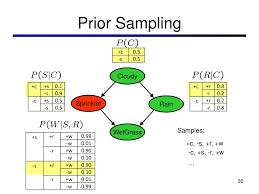
- You repeat random sampling of the parents for each full sample. Effectivley creating new 'highlights' each sample?
- Steps:
  - For each variable $X_i$, sample its value from its CPT given the values already sampled for its parents: $x_i \sim P(X_i \mid Parents(X_i))$
  - Each full sample (+c,-s, +r, +w) is generated with probability exactly equal to the joint probability defined by bayes net: $P(x_1, x_2, \dots, x_n) = \prod_i P(x_i \mid parents(x_i))$
  - Generate a large number N of samples
    - For any query (P(W=+w)) count how many samples satisfy the event and normalize: $\hat{P}(W = +w) \approx \frac{\# \text{ samples with } +w}{N}$
    - You can estimate any marginal, joint, or even conditional probability this way (by looking at the relevant subset of variables in the samples).

### Example:
- Get these fromt the BN:
```
+c, -s, +r, +w
+c, +s, +r, +w
-c, +s, +r, -w
+c, -s, +r, +w
-c, -s, -r, +w
```
- If we want to know P(W)
- We have counts <+w:4, -w:1>
- Normalize to get P(W) = <+w:0.8, -w:0.2>

## Rejection Sampling
- Say we want P(C)
  - There is no point keeping all samples around
  - Just Tally counts of C as we go
  - Recall: P(C) = the entire distribtion of C - what % are positive AND what % are negative
- Say we want P(C|+s)
  - Same thing: tally C outcomes but ignore (**reject**) samples which don't have S=+s.
  - This is called rejection sampling
  - Also consistent for conditional probailities (as # of samples approach infinity, the estimat P(C) will approach it's true value)

- General Formula:
  - Input: evidence instantiation (anything on the right side of `|`)
  - For i = 1,2,...,n
    - sample $x_i$ from $P(X_i|Parents(X_i))$
      - THis is generating a full sample using *Prior sampling*
    - If $x_i$ is not consistent with evidence
      - Reject: return - no sample is generated in this cycle
    - Return $(x_1,x_2,...,x_n)$

## Likelihood Weighting
- Issue with rejection sampling is:
  - If evidence is unlikely, rejects lots of samples.
  - Evidence not exploited as you sample (uses prior sampling)
- Idea: fix evidence variables and sample the rest
  - Problem: sample distribution not consistent as its not randomly selected
  - Solve that by weighting by probability of evidence given parents.  

- Normal nodes: Sampled randomly using their CPTs
- Slashed Nodes: Evidence variables
  - We don't sample them and fix them to their observed value.

### Pseudocode
- Input: evidence instantiation
- w = 1.0
- for i = 1,2,...,n (every variable)
  - If $X_i$ is an evidence variable
    - $X_i$ = observation $x_i$ for $X_i$ // fixed
    - Set w = w * $P(x_i|Parents(X_i))$
      - Weight only gets multiplied by a parent when that parent is an evidence variable.
  - else:
    - Sample $x_i$ from $P(x_i|Parents(X_i))$ like normal prior sampling

- Likeliehood weighting combines sampling and weights to make the weighted sampling distribution consistent: $S_{WS}(z, e) \cdot w(z, e) =
\prod_{i=1}^{l} P(z_i \mid \text{Parents}(z_i))
\cdot
\prod_{i=1}^{m} P(e_i \mid \text{Parents}(e_i))
= P(z, e)$
### Assessment
- Why it's good:
  - We have taken evidence into account as we generate the sample
  - More of our samples will reflect the state of the world suggested by the evidence
- Doesn't solve all of our problems
  - Evidence influences the choice of downstream variables, but not upstream
    - Upstream variables are sampled as if we had no evidence atall, which isn't right in some cases. Think fire example
  - We would like to consider evidence when we sample every variable, not just if it is a evidence variable.

## Gibbs Sampling
- Procedure
  - Keep track of full instantiation $x_1, x_2, ..., x_n$.
    - An **complete** assignment of all variables
  - Start with an arbitrary (random) instantiation consistent with the evidence.
  - Sample one variable at a time, conditioned on all the rest, but keep evidence fixed.
    - Keep repeating this for a long time.
- In the limit of repeating this infinitely, the resulting samples come for the correct distribution (means its conditioned on evidence)
- Here, both upstream and downstream variables condition on evidence
- **In contrast** - likelihood only conditions on upstreams evidence hence weights sometimes come out very small
### Example:

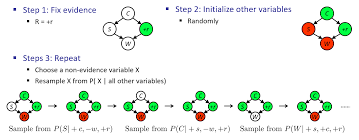

### Math behind resampling one variable:



-Sample from $P(S \mid +c, +r, -w)$

$$
P(S \mid +c, +r, -w) =
\frac{P(S, +c, +r, -w)}{P(+c, +r, -w)}
\qquad \text{(def. of conditional probability)}
$$

$$
= \frac{P(S, +c, +r, -w)}{\sum_s P(s, +c, +r, -w)}
\qquad \text{(introduce summation)}
$$

$$
= \frac{P(+c)P(S \mid +c)P(+r \mid +c)P(-w \mid S, +r)}
{\sum_s P(+c)P(s \mid +c)P(+r \mid +c)P(-w \mid s, +r)}
\qquad \text{(def. of Bayes' Nets)}
$$

$$
= \frac{P(+c)P(S \mid +c)P(+r \mid +c)P(-w \mid S, +r)}
{P(+c)P(+r \mid +c) \sum_s P(s \mid +c)P(-w \mid s, +r)}
\qquad \text{(move summation term out)}
$$

$$
= \frac{P(S \mid +c)P(-w \mid S, +r)}
{\sum_s P(s \mid +c)P(-w \mid s, +r)}
\qquad \text{(cancel out terms)}
$$

- **Many things cancel out** — only CPTs with **S** remain!
- More generally: Only CPTs that have the **resampled variable** need to be considered, and joined together.